# Análise Estatística do Backend - GTA V / Steam Reviews (Dataset Real)

Este notebook demonstra a pipeline de classificação de reviews baseada em propagação de rótulos (Label Propagation) usando um grafo tripartido.

O foco é validar:
- O carregamento dos dados reais (`steam_reviews_ptbr_top_game.csv`) e pré-processamento.
- O balanceamento das categorias preditas.
- A distribuição de confiança nas predições do algoritmo.
- A curva de convergência do algoritmo ao longo das iterações.
- As palavras mais influentes por categoria via pesos acumulados (TF-IDF).

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "backend").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

ROOT

WindowsPath('C:/Users/pedrohpsantos/Documents/steam-review-classification')

## Carregamento e Preparação dos Dados
Ao invés de dados mockados, usamos o arquivo `steam_reviews_ptbr_top_game.csv`. Devido à complexidade computacional da construção do grafo e propagação (O(N²)), estamos usando uma amostra aleatória de 500 reviews.

In [2]:
import pandas as pd
import numpy as np

# Carregar dados reais (amostra de 500 para performance)
dataset_path = ROOT / "datasets" / "steam_reviews_ptbr_top_game.csv"
df = pd.read_csv(dataset_path)

# Remover reviews vazios ou que não possuam tokens processados
df = df.dropna(subset=['clean_tokens'])
df_sample = df.sample(n=500, random_state=42).copy()

# Transformar os tokens em listas para o builder do grafo
# Exemplo de entrada: "fps lag crash" -> Saída: ['fps', 'lag', 'crash']
df_sample['tokens_list'] = df_sample['clean_tokens'].apply(lambda x: str(x).split())

# Criar a estrutura 'documents' esperada pelo backend: (review_id, [tokens])
documents = list(zip(df_sample['review_id'].astype(str), df_sample['tokens_list']))

print(f"Total de documentos extraídos: {len(documents)}")
print(f"Exemplo: {documents[0]}")

Total de documentos extraídos: 500
Exemplo: ('39126057', ['ótim', 'jog', 'faz', 'quas', 'tud', 'quer'])


## Construção do Grafo e Propagação
Instanciamos o grafo conectando as `reviews`, as `palavras` (TF-IDF/PMI) e as categorias âncoras (Sementes).

In [3]:
from backend.graph.builder import build_tripartite_graph, mock_seed_groups
from backend.preprocessing.tf_idf import calculate_tf_idf
from backend.propagation.label_propagation import classify_reviews, label_propagation_with_history

seed_groups = mock_seed_groups()

print("Construindo grafo (isso pode demorar alguns segundos)...")
graph = build_tripartite_graph(documents, seed_groups)

print("Rodando Label Propagation...")
scores, convergence_history = label_propagation_with_history(graph, iterations=30, threshold=0.0001)

print("Classificando reviews...")
classifications = classify_reviews(graph, scores)
tf_idf_weights = calculate_tf_idf(documents)

print(f"Classificações geradas: {len(classifications)}")

Construindo grafo (isso pode demorar alguns segundos)...


Rodando Label Propagation...


Classificando reviews...
Classificações geradas: 500


## Curva de Convergência do Algoritmo
O histórico da convergência mostra como o `delta` (mudança máxima na pontuação de todos os nós) diminui a cada iteração até atingir o limiar de parada.

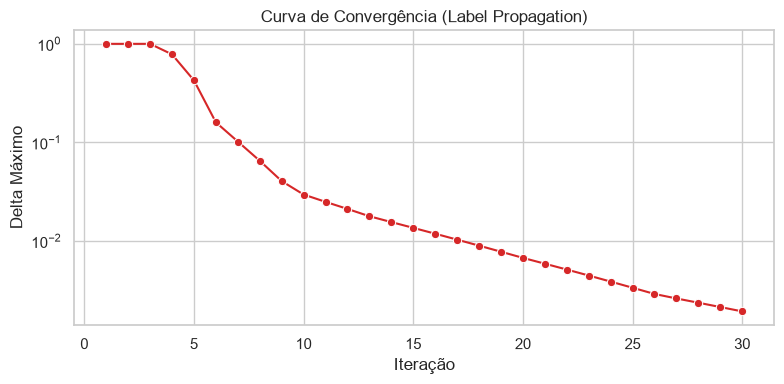

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# convergence_history é uma lista de (iteração, delta)
iterations = [h[0] for h in convergence_history]
deltas = [h[1] for h in convergence_history]

plt.figure(figsize=(8, 4))
sns.lineplot(x=iterations, y=deltas, marker="o", color="#d62728")
plt.title("Curva de Convergência (Label Propagation)")
plt.xlabel("Iteração")
plt.ylabel("Delta Máximo")
plt.yscale('log') # Escala logarítmica é melhor para ver a convergência
plt.tight_layout()
plt.show()

## Balanceamento e Distribuição de Confiança
Analisamos a quantidade de reviews classificadas em cada categoria, e o quão "confiante" o algoritmo esteve nestas predições.

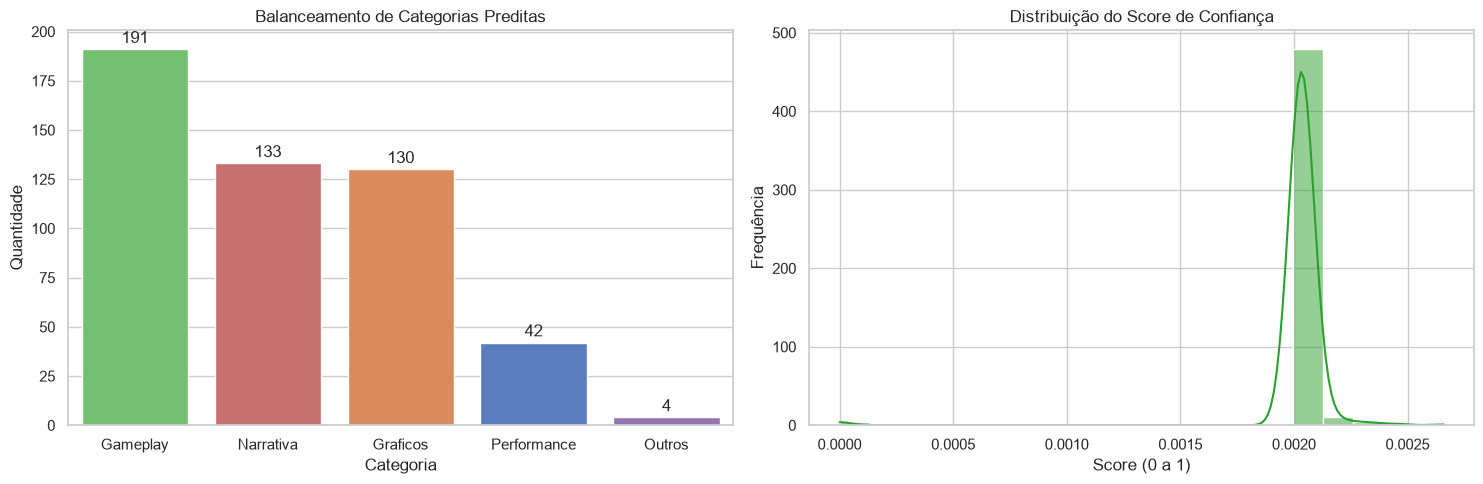

In [5]:
# Criar um DataFrame com os resultados das classificações
results = []
for review_id, pred_category, pred_score, all_scores in classifications:
    results.append({
        'review_id': review_id,
        'predicted_category': pred_category,
        'confidence_score': pred_score
    })

df_results = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Contagem por Categoria
sns.countplot(data=df_results, x='predicted_category', hue='predicted_category', legend=False,
              palette="muted", ax=axes[0],
              order=df_results['predicted_category'].value_counts().index)
axes[0].set_title("Balanceamento de Categorias Preditas")
axes[0].set_xlabel("Categoria")
axes[0].set_ylabel("Quantidade")
for container in axes[0].containers:
    axes[0].bar_label(container, padding=2)

# Gráfico 2: Distribuição dos Scores
sns.histplot(data=df_results, x='confidence_score', bins=20, 
             kde=True, color="#2ca02c", ax=axes[1])
axes[1].set_title("Distribuição do Score de Confiança")
axes[1].set_xlabel("Score (0 a 1)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

## Análise Semântica (WordClouds)
Usando os pesos de TF-IDF extraídos de cada review, calculamos quais palavras mais "puxaram" a classificação final. Isso serve como mecanismo de explicabilidade do modelo.

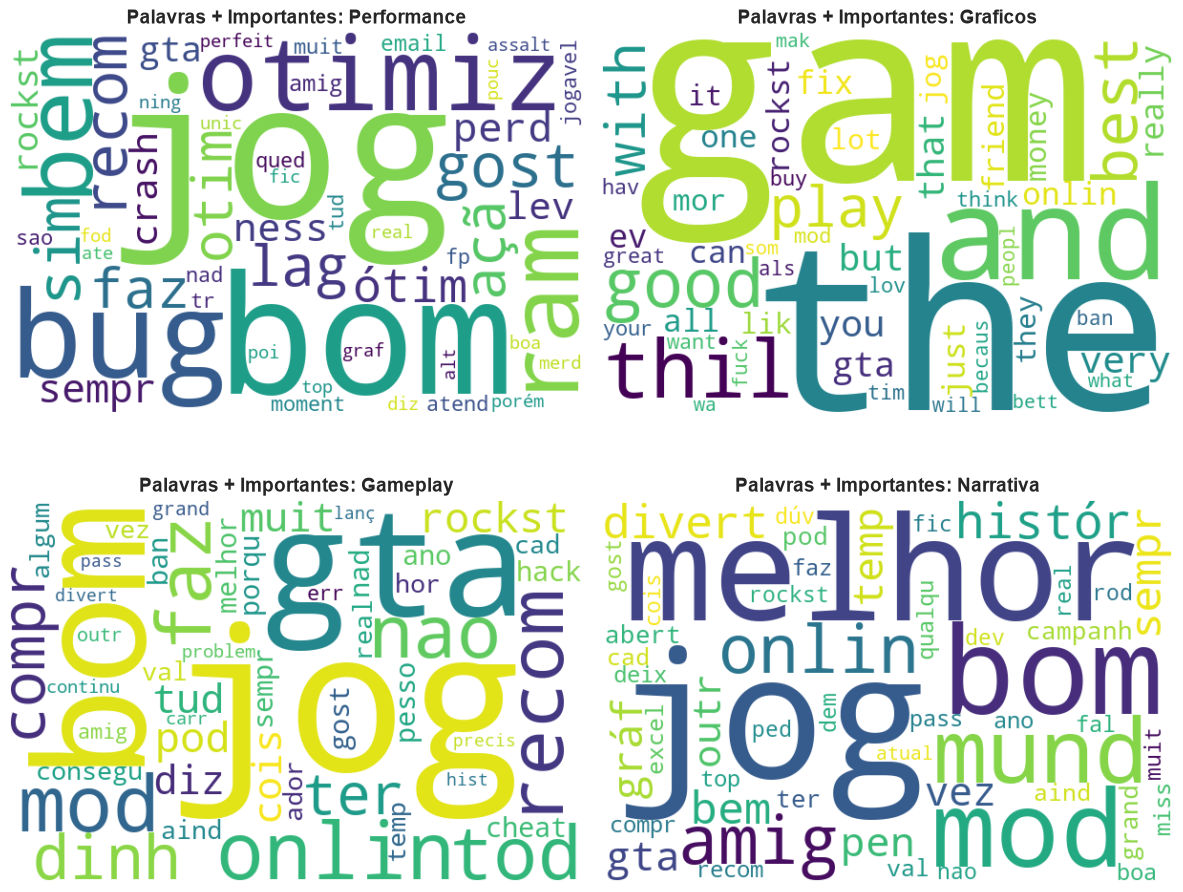

In [6]:
from wordcloud import WordCloud

# Agrupar os pesos acumulados por categoria usando Pandas
# Primeiro, construímos uma tabela simples
rows = []
for review_label, pred_cat, _, _ in classifications:
    # Pegar os pesos TF-IDF para a review
    terms = next((w for r, w in tf_idf_weights if r == review_label), [])
    for word, weight in terms:
        rows.append({'category': pred_cat, 'word': word, 'weight': weight})

df_words = pd.DataFrame(rows)

# Somar os pesos para as mesmas palavras na mesma categoria
df_grouped = df_words.groupby(['category', 'word'])['weight'].sum().reset_index()

categories = [seed[0] for seed in seed_groups]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, category in enumerate(categories):
    # Filtrar dados para a categoria atual
    cat_data = df_grouped[df_grouped['category'] == category]
    
    if len(cat_data) == 0:
        axes[i].axis("off")
        axes[i].set_title(f"{category} (Sem dados)")
        continue
        
    # Converter para dicionário: word -> sum(weight)
    word_freq = dict(zip(cat_data['word'], cat_data['weight']))
    
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap='viridis', max_words=50).generate_from_frequencies(word_freq)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis("off")
    axes[i].set_title(f"Palavras + Importantes: {category}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()